mehrere hist inputs weg nur eins und dann mit slice arbeiten

In [1]:
import sys
from pathlib import Path

sys.path.insert(0, str(Path.cwd().parent.parent))

import mesmer
import model
import model_analysis

import importlib
import matplotlib.pyplot as plt
import xarray as xr
import pandas as pd

import numpy as np
from scipy.stats import skewnorm

import cartopy.crs as ccrs



In [2]:
max_radius = 4
hist = 1
is_local_data = True
Month_idx = 4
safe = True
start_wanted = None  # later this will be shifted, if it is to close to the beginning of the data, such that there is allways data also for the hist dimension
end = None
max_depth = 3


### Load parameters of the transformations

In [4]:
parameter_sets = {}
for i in range(0,max_radius):
    key = f"radius_{i}"
    parameter_sets[key] = model.loading.load_params(var = "mrsol",scen= "historical", folder = f"MPI-ESM1-2-LR/variations/radius/{key}/local{is_local_data}/month{Month_idx}", name=f"start={start_wanted},end={end}.max_depth{max_depth}")    

the mask should only change if one is based on relative data, and one is abs because the threshold has a diffrent effect

In [6]:
for para_key,para in parameter_sets.items():
    print(parameter_sets["radius_1"]["detail_mask"].equals(para["detail_mask"]))

chunk_mask = parameter_sets["radius_1"]["chunk_mask"]


True
True
True
True


In [7]:
for para_key,para in parameter_sets.items():
    print(parameter_sets["radius_1"]["chunk_mask"].equals(para["chunk_mask"]))

detal_mask = parameter_sets["radius_1"]["detail_mask"]


True
True
True
True


In [8]:
for para_key,para in parameter_sets.items():
    print(parameter_sets["radius_1"]["local_maximas"].equals(para["local_maximas"]))

max = model.mask.mask_mask(parameter_sets["radius_1"]["local_maximas"],parameter_sets["radius_1"]["chunk_mask"].mrsol).isel(depth=slice(0, max_depth))
maximas = mesmer.grid.stack_lat_lon(max).drop_vars("depth_bnds").transpose("gridcell","depth").mrsol


True
True
True
True


### Load test input and target

In [9]:
run_idx = 4
raw_mrsol_for_test = model.loading.load_data_set(var = "mrsol", local = is_local_data, run_idx=run_idx)

tas_ds = model.loading.load_data_set(var = "tas", local = is_local_data, run_idx=run_idx)
pr_ds = model.loading.load_data_set(var = "pr", local = is_local_data, run_idx=run_idx)

raw_input_for_test = xr.merge([tas_ds,pr_ds]).drop_vars("file_qf")


In [10]:
#min_start 

data_start = pd.to_datetime(raw_mrsol_for_test.time[0].item())
offset = pd.tseries.frequencies.to_offset("ME")
min_start = data_start + pd.DateOffset(months=max_radius)

if start_wanted is None:
    start = min_start
else:
    start = pd.to_datetime(start_wanted) 
    start = max(min_start,start)
start = start.strftime("%Y-%m-%d")  

### shape inputs

In [11]:
def shape_input(ds, chunk_mask, hist, radius):
    ds = model.shape_data.add_hist_dimension(ds, hist)    
    ds = ds.sel(time=slice(start, end)).resample(time="ME").mean()
    ds = ds.sel(time= ds.time.dt.month == Month_idx)
    ds = model.shape_data.add_radius_dimension(ds, radius)
    ds = model.mask.mask_mask(ds,chunk_mask)
    ds = mesmer.grid.stack_lat_lon(ds)
    return ds
   

In [12]:
test_predictor_sets  = {}
test_max_predictor = shape_input(raw_input_for_test,chunk_mask.mrsol,hist,max_radius)

for radius in range(0, max_radius):
    test_predictor_sets[f"radius_{radius}"] = test_max_predictor.sel(lon_translations=slice(-radius,radius)).sel(lat_translations=slice(-radius,radius))

### shape targets

In [13]:
def shape_target(ds):
    #ds = ds.clip(min = 1e-32)
    ds = ds.sel(time=slice(start, end)).resample(time="ME").mean()
    ds = ds.sel(time= ds.time.dt.month == Month_idx).isel(depth=slice(0, max_depth)).drop_vars("depth_bnds")
    return ds

In [14]:
def mask_stack_target(ds):
    masked_ds, chunk_mask, detail_mask= model.mask.mask_nonpositiv_height_chunks(ds)
    ds = mesmer.grid.stack_lat_lon(masked_ds)
    ds = ds.transpose("gridcell","time", "depth")
    return ds

In [15]:
target_unstacked = shape_target(raw_mrsol_for_test)
target = mask_stack_target(target_unstacked)

glaub unnötig
rel transform
maximas = parameter_sets["rel_transform"]["local_maximas"]
rel_target = raw_mrsol_for_test/maximas
rel_target = shape_target(rel_target)
targets["rel"] = mask_stack_target(rel_target)

Log transform
log_target = shape_target(raw_mrsol_for_test)
log_target = mask_stack_target(log_target)
targets["log"] = model.transform.Log_Transform_ds(log_target)
Logit transform
maximas = parameter_sets["logit_transform"]["local_maximas"]
logit_target = raw_mrsol_for_test/maximas
logit_target = shape_target(logit_target)
logit_target = mask_stack_target(logit_target)
targets["logit"] = model.transform.Logit_Transform_ds(logit_target)

### Emulate

In [16]:
parameter_sets["radius_1"]["mean"]

<xarray.Dataset> Size: 175kB
Dimensions:           (gridcell: 378, depth: 3, hist: 1, lon_translations: 3,
                       lat_translations: 3)
Coordinates:
  * gridcell          (gridcell) int64 3kB 0 1 2 3 4 5 ... 373 374 375 376 377
  * depth             (depth) float64 24B 0.03 0.19 0.78
  * hist              (hist) int64 8B 0
  * lon_translations  (lon_translations) int64 24B -1 0 1
  * lat_translations  (lat_translations) int64 24B -1 0 1
Data variables:
    tas               (gridcell, depth, hist, lon_translations, lat_translations) float64 82kB ...
    pr                (gridcell, depth, hist, lon_translations, lat_translations) float64 82kB ...
    intercept         (gridcell, depth) float64 9kB 17.85 16.87 ... -0.3718
    fit_intercept     bool 1B True
Attributes:
    pred_dims:  ['hist', 'lon_translations', 'lat_translations']

In [17]:
predictions = {}

In [18]:
test_predictor_sets["radius_1"]

<xarray.Dataset> Size: 9MB
Dimensions:           (hist: 1, time: 164, lon_translations: 3,
                       lat_translations: 3, gridcell: 378)
Coordinates:
  * hist              (hist) int64 8B 0
  * time              (time) datetime64[ns] 1kB 1851-04-30 ... 2014-04-30
  * lon_translations  (lon_translations) int64 24B -1 0 1
  * lat_translations  (lat_translations) int64 24B -1 0 1
    lat               (gridcell) float64 3kB -51.75 -47.25 ... 78.75 78.75
    lon               (gridcell) float64 3kB 288.0 288.0 288.0 ... 279.0 297.0
    height            float64 8B 2.0
Dimensions without coordinates: gridcell
Data variables:
    tas               (lat_translations, lon_translations, time, hist, gridcell) float64 4MB ...
    pr                (lat_translations, lon_translations, time, hist, gridcell) float64 4MB ...
Attributes: (12/52)
    CDI:                       Climate Data Interface version 1.9.6 (http://m...
    history:                   Wed Jul 15 10:14:37 2026: cdo remapbil,r40x40 ...
    source:                    MPI-ESM1.2-LR (2017): \naerosol: none, prescri...
    institution:               Max Planck Institute for Meteorology
    Conventions:               CF-1.7 CMIP-6.2
    activity_id:               CMIP
    ...                        ...
    cmor_version:              3.5.0
    tracking_id:               hdl:21.14100/664bf0d5-5ae5-48aa-bb2a-f71acf46386c
    cmip6-ng:                  \ncontact = cmip6-archive@env.ethz.ch\ndescrip...
    original_file_names:       /net/atmos/data/cmip6/historical/Amon/tas/MPI-...
    original_file_hash_codes:  1f97bc429d1731b47b6a0c3b1e5945fbd188e5e87b56be...
    CDO:                       Climate Data Operators version 1.9.6 (http://m...

In [19]:
para["mean"].attrs

{'pred_dims': ['hist', 'lon_translations', 'lat_translations']}

In [20]:
for key, para in parameter_sets.items():
    predictions[key] = {}

    Regr_mean = model.stats._parallel_linear_regression_stack.ParLinearRegressionStack(predictor_dims=["hist"])
    Regr_mean = Regr_mean.from_params(para["mean"])
    predictions[key]["mean"] = Regr_mean.predict(test_predictor_sets[key],location_dim="gridcell", regr_dim="time").transpose("gridcell","time", "depth")

    Regr_var = model.stats._parallel_linear_regression_stack.ParLinearRegressionStack(predictor_dims=["hist"])
    Regr_var = Regr_var.from_params(para["variance"])
    predictions[key]["variance"] = Regr_var.predict(test_predictor_sets[key],location_dim="gridcell", regr_dim="time").transpose("gridcell","time", "depth")

        

#### Scores

In [21]:
score_sets = {}


In [22]:
score_keys = parameter_sets.keys()
score_keys

dict_keys(['radius_0', 'radius_1', 'radius_2', 'radius_3'])

In [24]:
predictions.keys()
predictions["radius_2"].keys()

dict_keys(['mean', 'variance'])

In [25]:
for key in score_keys:
    score_sets[key] = model_analysis.crps_score.crps_norm_score(predictions[key]["mean"],predictions[key]["variance"], target, transformation = "Logit", maximas_da = maximas,ensemble_size = 15)

In [26]:
for s_keys, scores in score_sets.items():
    score_sets[s_keys] = mesmer.grid.unstack_lat_lon_and_align(scores, target_unstacked)
    
    score_sets[s_keys] = model.mask.mask_mask(score_sets[s_keys],detal_mask.mrsol,"lon", "lat", "depth")
    

In [27]:
all_scores_ds =xr.Dataset({key : score.crps_score for key, score in score_sets.items()})

In [28]:
all_scores_ds.mean(dim=["lon","lat","time"])

<xarray.Dataset> Size: 120B
Dimensions:   (depth: 3)
Coordinates:
  * depth     (depth) float64 24B 0.03 0.19 0.78
Data variables:
    radius_0  (depth) float64 24B 0.3794 1.465 6.16
    radius_1  (depth) float64 24B 0.3461 1.481 6.238
    radius_2  (depth) float64 24B 0.3928 1.726 7.24
    radius_3  (depth) float64 24B 0.5328 2.371 9.747

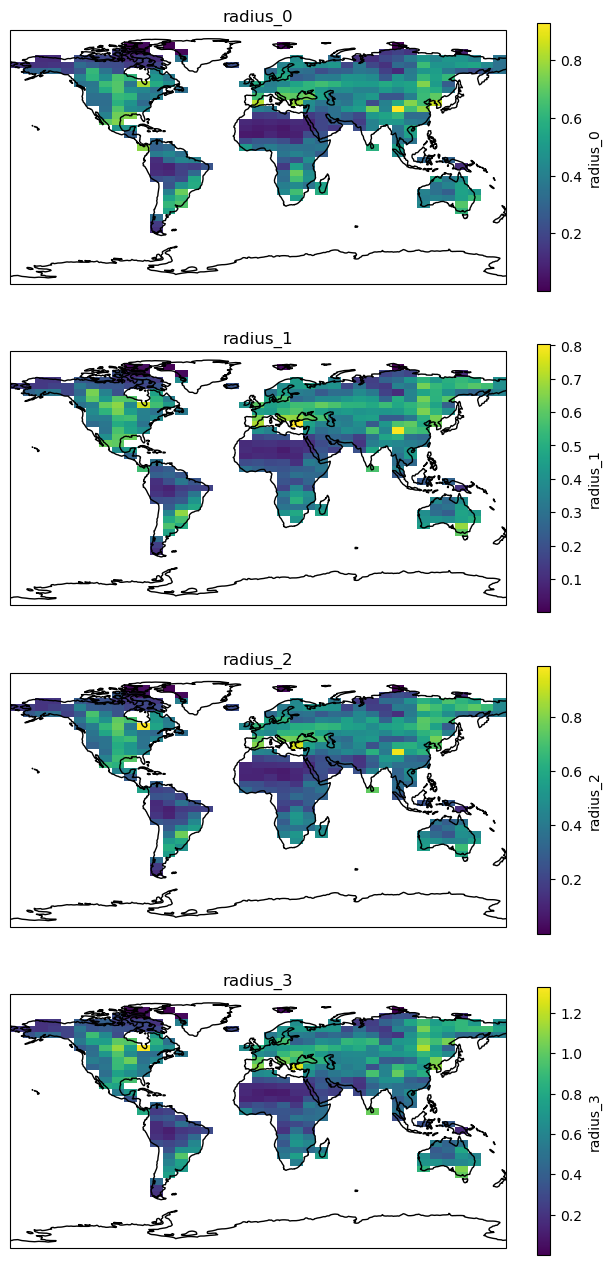

In [33]:
fig_global_crpss, ax = plt.subplots(
    subplot_kw={"projection": ccrs.PlateCarree()},
    nrows=len(score_keys),
    ncols=1,
    figsize=(8, 4 * len(score_keys))
)
depth = 0

for i, s_key in enumerate(score_keys):
    da = all_scores_ds.isel(depth=depth).mean("time")[s_key]
    da.plot(ax=ax[i])
    ax[i].coastlines()
    ax[i].set_title(s_key)



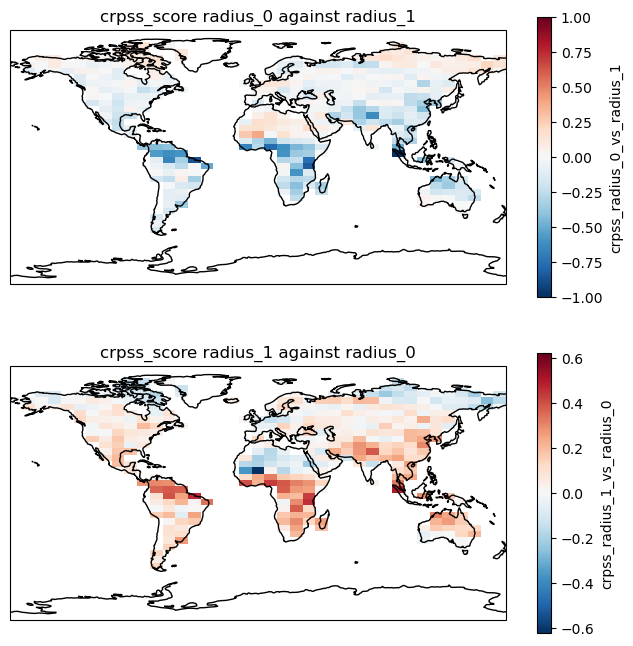

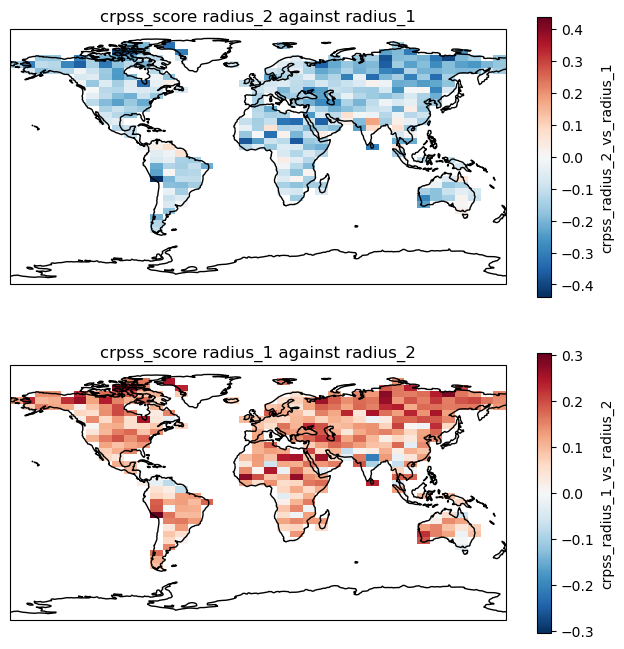

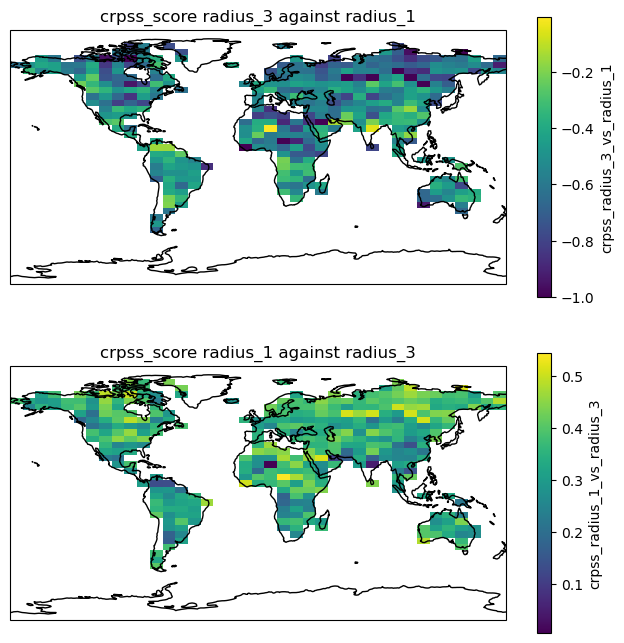

In [32]:
depth = 0

choice = "radius_1"

for i, s_key in enumerate(score_keys):
    if s_key == choice:
        continue
    vs = model_analysis.crps_score.combine_two_crps_and_the_crpss(score_sets[choice].crps_score,score_sets[s_key].crps_score,choice,s_key)

    fig_global_crpss, ax = plt.subplots(
    subplot_kw={"projection": ccrs.PlateCarree()},
    nrows=2,
    ncols=1,
    figsize=(8, 8)
    )
    """
    da = vs.isel(depth=depth).mean("time")[s_key]
    da.plot(ax=ax[0])
    ax[0].coastlines()
    ax[0].set_title(s_key)

    da = vs.isel(depth=depth).mean("time")[choice]
    da.plot(ax=ax[1])
    ax[1].coastlines()
    ax[1].set_title(choice)
    """
    da = vs.isel(depth=depth)[f"crpss_{s_key}_vs_{choice}"].clip(min=-1)
    da.plot(ax=ax[0])
    ax[0].coastlines()
    ax[0].set_title(f"crpss_score {s_key} against {choice}")

    da = vs.isel(depth=depth)[f"crpss_{choice}_vs_{s_key}"].clip(min=-1)
    da.plot(ax=ax[1])
    ax[1].coastlines()
    ax[1].set_title(f"crpss_score {choice} against {s_key}")

    fig_global_crpss.show()
    
